
# SMaLL-100 (zh->en) — Fine-tuning (Wuxia Domain)

**TFG Hugo Silvosa – Baseline NMT (SMaLL-100)**  
Este cuaderno entrena y evalúa un modelo **SMaLL-100** (`alirezamsh/small100`) usando un dataset de  **wuxia** (chino->inglés) ya preparado en formato `datasets` (HF).





## 1) Preparación del entorno

In [1]:

import os, random, math
import numpy as np

import torch
print("CUDA disponible:", torch.cuda.is_available())
print("Número de GPUs:", torch.cuda.device_count())
if torch.cuda.is_available():
    print("Nombre de la GPU:", torch.cuda.get_device_name(0))



CUDA disponible: True
Número de GPUs: 1
Nombre de la GPU: NVIDIA GeForce RTX 3060



> **Requisitos del dataset**: directorio HF Datasets con *splits* `train`, `validation`, `test` y columnas `zh` (chino) y `en` (inglés):  
> `processed_data/wuxia_zh_en_clean/`

In [2]:
# Configuración de carpetas para entorno LOCAL
from pathlib import Path
BASE_DIR = Path.cwd().parent
BASE_DIR.mkdir(exist_ok=True)

# Estructura repositorio
for sub in ["evaluation", "models", "processed_data"]:
    (BASE_DIR / sub).mkdir(parents=True, exist_ok=True)

print("Base:", BASE_DIR.resolve())
print("Estructura creada (si no existía):")
for p in ["evaluation", "models", "proccesed data"]:
    print(" -", (BASE_DIR / p).resolve())

# Nota: el dataset debe existir en: CORPUS/proccesed data/wuxia_zh_en_clean


Base: C:\Users\Usuario\Desktop\TFG\CORPUS
Estructura creada (si no existía):
 - C:\Users\Usuario\Desktop\TFG\CORPUS\evaluation
 - C:\Users\Usuario\Desktop\TFG\CORPUS\models
 - C:\Users\Usuario\Desktop\TFG\CORPUS\proccesed data


## 2) Configuración

In [3]:
from dataclasses import dataclass

@dataclass
class Config:
    # Rutas (local)
    dataset_dir: Path  = BASE_DIR / "processed_data" / "wuxia_zh_en_clean"   # <- carpeta con dataset HuggingFace guardado con load_from_disk
    output_dir: Path   = BASE_DIR / "models" / "small100_wuxia"              # <- aquí se guardarán los runs/modelos
    ckpt_dir: Path     = BASE_DIR / "checkpoints"                          # <- checkpoints durante entrenamiento
    training_dir: Path = BASE_DIR / "training"         
    evaluation_dir: Path = BASE_DIR / "evaluation"
    translate_dir: Path = BASE_DIR / "evaluation" / "translate"
    translate_file: Path =  "small100.txt"
    results_file: Path = "results.txt"
    
    # Columnas del dataset
    src_col: str = "zh"
    tgt_col: str = "en"

    # Modelo
    src_lang: str = "zh"
    tgt_lang: str = "en"
    model_ckpt: str = "alirezamsh/small100"

    # Entrenamiento
    seed: int = 42
    max_source_length: int = 128
    max_target_length: int = 128
    batch_size: int = 16
    epochs: int = 10
    learning_rate: float = 2e-5
    weight_decay: float = 0.01
    early_stopping_patience: int = 2

    fraction: float = 1

cfg = Config()
print(cfg)


Config(dataset_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/processed_data/wuxia_zh_en_clean'), output_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/models/small100_wuxia'), ckpt_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/checkpoints'), training_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/training'), evaluation_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/evaluation'), translate_dir=WindowsPath('c:/Users/Usuario/Desktop/TFG/CORPUS/evaluation/translate'), translate_file='small100.txt', results_file='results.txt', src_col='zh', tgt_col='en', src_lang='zh', tgt_lang='en', model_ckpt='alirezamsh/small100', seed=42, max_source_length=128, max_target_length=128, batch_size=16, epochs=10, learning_rate=2e-05, weight_decay=0.01, early_stopping_patience=2, fraction=1)


In [4]:
import random, numpy as np, os

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando dispositivo:", device)



# Semillas para reproducibilidad
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
random.seed(cfg.seed)
os.environ["PYTHONHASHSEED"] = str(cfg.seed)


if device.type == "cuda":
    torch.cuda.manual_seed_all(cfg.seed)
    # Para reproducibilidad estricta 
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print("Semillas fijadas y backend configurado.")


Usando dispositivo: cuda
Semillas fijadas y backend configurado.


## 3) Cargar dataset (Hugging Face Datasets)

In [5]:

from datasets import load_from_disk, DatasetDict

assert os.path.isdir(cfg.dataset_dir), f"No se encuentra el dataset en: {cfg.dataset_dir}"
raw_ds: DatasetDict = load_from_disk(cfg.dataset_dir)
print(raw_ds)

# Validar columnas
def _check_cols(ds, src_col, tgt_col, split):
    cols = ds.column_names
    assert src_col in cols and tgt_col in cols, f"El split '{split}' debe contener columnas '{src_col}' y '{tgt_col}'. Columnas: {cols}"

for split in ["train", "validation", "test"]:
    assert split in raw_ds, f"Falta el split '{split}' en el dataset."
    _check_cols(raw_ds[split], cfg.src_col, cfg.tgt_col, split)

#  pruebas rápidas
def take_fraction(ds, frac, seed=42):
    if frac >= 1.0:
        return ds
    n = max(1, int(len(ds) * frac))
    return ds.shuffle(seed=seed).select(range(n))

train_ds = take_fraction(raw_ds["train"], cfg.fraction, seed=cfg.seed)
val_ds   = take_fraction(raw_ds["validation"], cfg.fraction, seed=cfg.seed)
test_ds  = take_fraction(raw_ds["test"], cfg.fraction, seed=cfg.seed)

print(train_ds[:2])
print(f"Tam. train/val/test (fracción={cfg.fraction}):", len(train_ds), len(val_ds), len(test_ds))


DatasetDict({
    train: Dataset({
        features: ['zh', 'en'],
        num_rows: 417208
    })
    validation: Dataset({
        features: ['zh', 'en'],
        num_rows: 52151
    })
    test: Dataset({
        features: ['zh', 'en'],
        num_rows: 52151
    })
})
{'zh': ['第章 听到白小纯的话语，看到圣皇的迟疑，邪皇这里顿时呼吸一促，他目中刹那就露出凌厉之芒，右手猛的一挥，顿时那残破的红日，骤然幻化', '尤其是看到人群内的宋缺时，神算子立刻警惕，他当年在空城，是第一个跟随白小纯的，受到了重用，如今却成为了第二个，他顿时就视宋缺为竞争对手'], 'en': ['chapter- The Saint-Emperor hesitated, and the Vile-Emperor sucked in a breath, eyes flickering with cold light as he waved his hand to summon his damaged red sun', 'That was even more the case when he noticed Song Que among Bai Xiaochun’s men, which immediately got him even more on guard. Back in Sky City, Master God-Diviner had been the first to start following Bai Xiaochun again, and it had led to incredible benefits. Now, he was only the second to join him, which put Song Que in his sights as a major rival']}
Tam. train/val/test (fracción=1): 417208 52151 52151

## 4) Cargar tokenizador y modelo 

In [6]:
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
# Tokenizer
tokenizer = AutoTokenizer.from_pretrained(cfg.model_ckpt)


model = AutoModelForSeq2SeqLM.from_pretrained(cfg.model_ckpt)
model.to(device)

# Info útil
n_params = sum(p.numel() for p in model.parameters())
print(f"Modelo cargado: {cfg.model_ckpt}")
print(f"Parámetros totales: {n_params:,}")

Modelo cargado: alirezamsh/small100
Parámetros totales: 332,735,488


## 5) Preprocesamiento y tokenización

In [7]:
# Función para tokenizar ejemplos
def preprocess_function(examples):
    src_list = examples[cfg.src_col]
    tgt_list = examples[cfg.tgt_col]

    cleaned_src, cleaned_tgt = [], []
    for s, t in zip(src_list, tgt_list):
        s = (s or "").strip()
        t = (t or "").strip()
        if s and t:
            cleaned_src.append(s)
            cleaned_tgt.append(t)

    # Idiomas 
    # Para inputs:
    try:
        tokenizer.src_lang = cfg.src_lang
    except Exception:
        pass

    model_inputs = tokenizer(
        cleaned_src,
        max_length=cfg.max_source_length,
        truncation=True,
        padding=False,
    )

    # Para labels: antes de usar text_target, se fija tgt_lang
    try:
        tokenizer.tgt_lang = cfg.tgt_lang
    except Exception:
        pass

    labels = tokenizer(
        text_target=cleaned_tgt,
        max_length=cfg.max_target_length,
        truncation=True,
        padding=False,
    )
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

# Aplicar tokenización a todo el dataset
tokenized_datasets = raw_ds.map(
    preprocess_function,
    batched=True,
    remove_columns=raw_ds["train"].column_names
)

train_ds = take_fraction(tokenized_datasets["train"], cfg.fraction, seed=cfg.seed)
val_ds   = take_fraction(tokenized_datasets["validation"], cfg.fraction, seed=cfg.seed)
test_ds  = take_fraction(tokenized_datasets["test"], cfg.fraction, seed=cfg.seed)

print(train_ds[0])

Map:   0%|          | 0/52151 [00:00<?, ? examples/s]

{'input_ids': [128102, 36741, 31659, 22, 18502, 1885, 10195, 2564, 89547, 36664, 29163, 4, 16501, 60116, 44253, 80, 117835, 21082, 4, 91101, 44253, 37256, 51147, 3720, 27321, 32282, 971, 51262, 4, 1957, 8257, 1203, 124909, 5133, 2354, 26528, 1799, 96983, 118223, 4326, 121938, 4, 49121, 2382, 104686, 9600, 116861, 4, 51147, 3720, 5133, 21035, 22105, 80, 26512, 1273, 4, 122102, 11318, 79929, 3453, 2], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1], 'labels': [128022, 74070, 436, 7, 1658, 12369, 7, 35701, 1215, 178, 30318, 1776, 241, 4, 1019, 1197, 141, 421, 7, 35701, 1215, 178, 248, 119237, 28, 8, 120052, 4, 122301, 109150, 918, 150, 9792, 124249, 86770, 285, 1307, 84848, 241, 14810, 3972, 128, 4088, 5722, 14810, 9627, 117626, 5091, 4292, 2]}


## 6) Data collator 

In [8]:
from transformers import DataCollatorForSeq2Seq

# Se encarga de alinear dinámicamente las secuencias y crear batches listos para el modelo
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding="longest",   # Puedes usar "max_length" si quieres batches más uniformes
    return_tensors="pt",
    label_pad_token_id=-100
)

# Ejemplo de batch
batch = data_collator([train_ds[i] for i in range(2)])
for k, v in batch.items():
    print(f"{k}: shape={v.shape}, dtype={v.dtype}")

input_ids: shape=torch.Size([2, 62]), dtype=torch.int64
attention_mask: shape=torch.Size([2, 62]), dtype=torch.int64
labels: shape=torch.Size([2, 89]), dtype=torch.int64


## 7) Configuración de entrenamiento


> **Por defecto**          
> **Optimizador**: `AdamW` (con LR=2e-5, weight decay=0.01) de `Seq2SeqTrainer`   
> **Loss**: `CrossEntropyLoss` (token-level) de `AutoModelForSeq2SeqLM `

In [9]:

from transformers import Seq2SeqTrainingArguments, Seq2SeqTrainer

# Carpeta para resultados
run_dir = cfg.output_dir
run_dir.mkdir(parents=True, exist_ok=True)

# Argumentos de entrenamiento
training_args = Seq2SeqTrainingArguments(
    output_dir=str(run_dir),
    overwrite_output_dir=True,
    eval_strategy="epoch",                  # Evaluar al final de cada epoch
    save_strategy="epoch",                  # Guardar checkpoint por epoch
    save_total_limit=3,                      # Max nº de checkpoints guardados
    learning_rate=cfg.learning_rate,
    num_train_epochs=cfg.epochs,
    per_device_train_batch_size=cfg.batch_size,
    per_device_eval_batch_size=cfg.batch_size,
    weight_decay=cfg.weight_decay,
    logging_dir=str(run_dir / "logs"),
    logging_strategy="steps",
    logging_steps=50,
    predict_with_generate=True,              # Generar secuencias en validación
    fp16=torch.cuda.is_available(),          # Precisión mixta si hay GPU
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False
)

# Trainer para tareas Seq2Seq
trainer = Seq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    processing_class=tokenizer,
    data_collator=data_collator
)

print(" Seq2SeqTrainer configurado (PyTorch).")


 Seq2SeqTrainer configurado (PyTorch).


## 8) Cargar modelo + gráficas

In [10]:

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
import torch
import gc

try:
    del model
    del tokenizer
except NameError:
    pass
gc.collect()
torch.cuda.empty_cache()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

best_ckpt_path = getattr(trainer.state, "best_model_checkpoint", None)
if best_ckpt_path is None:
    # Fallback: usar output_dir si no hay checkpoint
    best_ckpt_path = cfg.output_dir
    print("o se encontró 'best_model_checkpoint'. Cargando desde output_dir final.")

print(f"Cargando modelo desde: {best_ckpt_path}")

tokenizer = AutoTokenizer.from_pretrained(best_ckpt_path)
model = AutoModelForSeq2SeqLM.from_pretrained(best_ckpt_path).to(device)

print("Mejor modelo y tokenizer cargados.")


Usando dispositivo: cuda
o se encontró 'best_model_checkpoint'. Cargando desde output_dir final.
Cargando modelo desde: c:\Users\Usuario\Desktop\TFG\CORPUS\models\small100_wuxia
Mejor modelo y tokenizer cargados.


 Información del entrenamiento:
  model_name: alirezamsh/small100
  epochs: 10
  batch_size: 16
  learning_rate: 2e-05
  weight_decay: 0.01
  train_size: 417208
  val_size: 52151
  metrics: {'train_runtime': 73452.0421, 'train_samples_per_second': 56.8, 'train_steps_per_second': 3.55, 'total_flos': 3.315308716990464e+17, 'train_loss': 1.2917136760298542, 'epoch': 10.0}

 Métricas finales de entrenamiento:
  epoch: 10.0
  total_flos: 3.315308716990464e+17
  train_loss: 1.2917136760298542
  train_runtime: 73452.0421
  train_samples_per_second: 56.8
  train_steps_per_second: 3.55

 Mejor checkpoint: c:\Users\Usuario\Desktop\TFG\CORPUS\models\small100_wuxia\checkpoint-260760


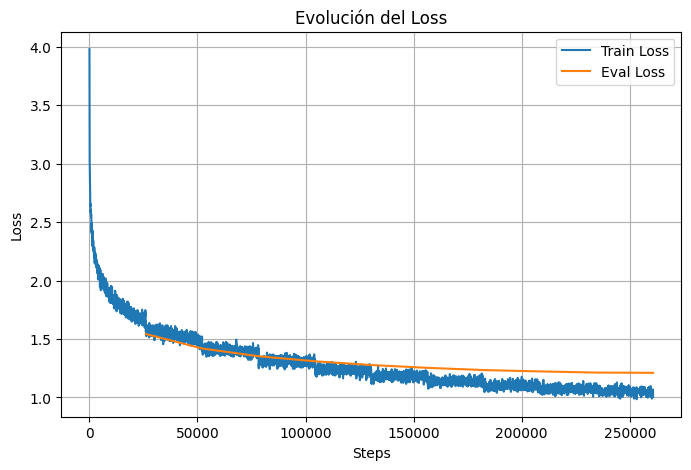

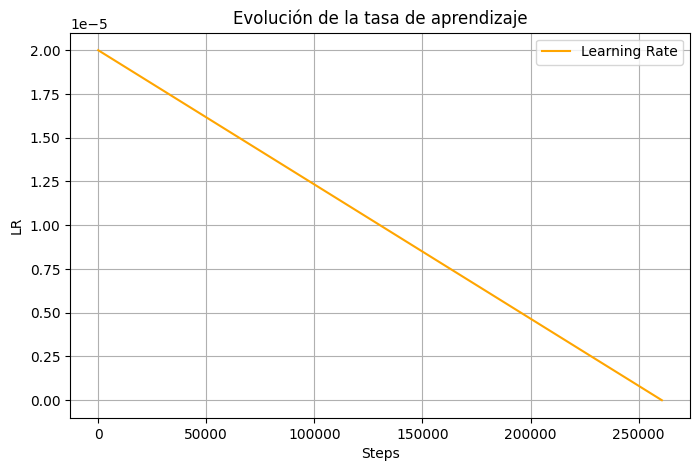

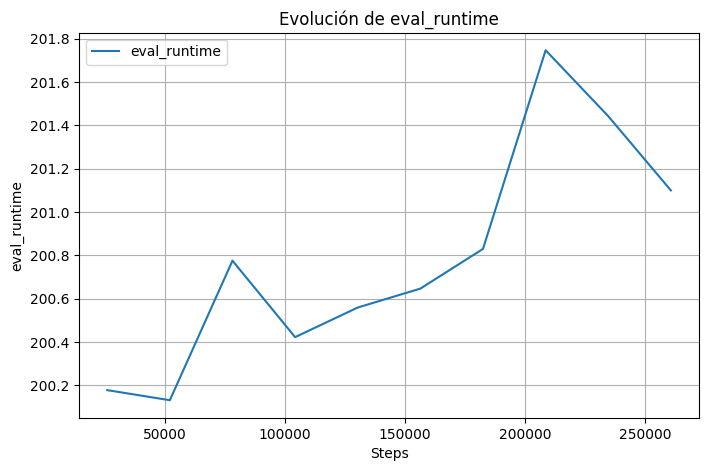

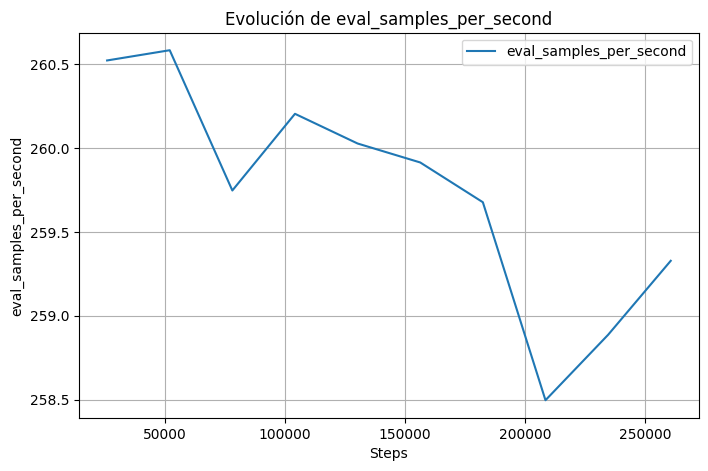

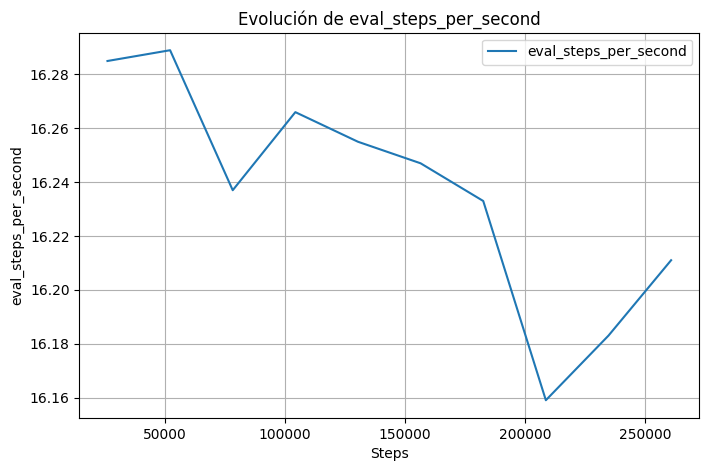

In [11]:

import json
import matplotlib.pyplot as plt
from pathlib import Path

#  Cargar info de la run 
run_info_path = Path(cfg.output_dir) / "run_info.json"
if run_info_path.exists():
    with open(run_info_path, "r", encoding="utf-8") as f:
        run_info = json.load(f)
    print(" Información del entrenamiento:")
    for k, v in run_info.items():
        print(f"  {k}: {v}")
else:
    print(f" No se encontró {run_info_path}")

#  Cargar métricas finales 
metrics_path = Path(cfg.output_dir) / "train_results.json"
if metrics_path.exists():
    with open(metrics_path, "r", encoding="utf-8") as f:
        train_metrics = json.load(f)
    print("\n Métricas finales de entrenamiento:")
    for k, v in train_metrics.items():
        print(f"  {k}: {v}")
else:
    print(f" No se encontró {metrics_path}")

#  Cargar trainer_state.json para histórico de entrenamiento 
log_history_path = Path(cfg.output_dir) / "trainer_state.json"
if log_history_path.exists():
    with open(log_history_path, "r", encoding="utf-8") as f:
        trainer_state = json.load(f)

    # Info del mejor checkpoint
    best_ckpt = trainer_state.get("best_model_checkpoint", None)
    if best_ckpt:
        print(f"\n Mejor checkpoint: {best_ckpt}")
    else:
        print("\n No se encontró información del mejor checkpoint.")

    # Historial de métricas
    log_history = trainer_state.get("log_history", [])

    # Extraer métricas y pasos
    steps_train = [entry["step"] for entry in log_history if "loss" in entry]
    train_loss = [entry["loss"] for entry in log_history if "loss" in entry]

    steps_eval = [entry["step"] for entry in log_history if "eval_loss" in entry]
    eval_loss = [entry["eval_loss"] for entry in log_history if "eval_loss" in entry]

    learning_rates = [entry["learning_rate"] for entry in log_history if "learning_rate" in entry]
    steps_lr = [entry["step"] for entry in log_history if "learning_rate" in entry]

    # Detectar métricas adicionales
    extra_metrics = {}
    for entry in log_history:
        for k, v in entry.items():
            if k.startswith("eval_") and k not in ["eval_loss"]:
                extra_metrics.setdefault(k, {"steps": [], "values": []})
                extra_metrics[k]["steps"].append(entry["step"])
                extra_metrics[k]["values"].append(v)

    #  Gráfica loss 
    plt.figure(figsize=(8,5))
    plt.plot(steps_train, train_loss, label="Train Loss")
    plt.plot(steps_eval, eval_loss, label="Eval Loss")
    plt.xlabel("Steps")
    plt.ylabel("Loss")
    plt.title("Evolución del Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

    #  Gráfica learning rate 
    if learning_rates:
        plt.figure(figsize=(8,5))
        plt.plot(steps_lr, learning_rates, label="Learning Rate", color="orange")
        plt.xlabel("Steps")
        plt.ylabel("LR")
        plt.title("Evolución de la tasa de aprendizaje")
        plt.legend()
        plt.grid(True)
        plt.show()

    #  Gráficas de métricas adicionales 
    for metric_name, data in extra_metrics.items():
        plt.figure(figsize=(8,5))
        plt.plot(data["steps"], data["values"], label=metric_name)
        plt.xlabel("Steps")
        plt.ylabel(metric_name)
        plt.title(f"Evolución de {metric_name}")
        plt.legend()
        plt.grid(True)
        plt.show()

else:
    print(f"No se encontró {log_history_path}")

## 9) Evaluación (SacreBLEU, chrF, TER, ROUGE-L, METEOR)

In [12]:

from tqdm.auto import tqdm
import sacrebleu
from sacrebleu.metrics import CHRF, TER
from rouge_score import rouge_scorer
import nltk
from nltk.translate.meteor_score import meteor_score
from nltk.tokenize import wordpunct_tokenize
import numpy as np
import torch


import time
start = time.time()

# Descargar recursos de NLTK (para METEOR)
nltk.download("wordnet", quiet=True)
nltk.download("omw-1.4", quiet=True)

#  Parámetros 
EVAL_MAX_SAMPLES = 1000        # None = todo el split
PRED_BEAMS = 4
BATCH_EVAL = max(1, cfg.batch_size // 2)

#  Comprobaciones 
assert 'model' in globals(), "No se encontró `model`. Carga el modelo antes."
assert 'tokenizer' in globals(), "No se encontró `tokenizer`. Cárgalo antes."
assert 'val_ds' in globals() and 'test_ds' in globals(), "Faltan `val_ds` y/o `test_ds`."
assert 'cfg' in globals(), "Falta `cfg`."

# Asegurar pad_token_id
if tokenizer.pad_token_id is None and tokenizer.eos_token_id is not None:
    tokenizer.pad_token_id = tokenizer.eos_token_id


#  Seleccionar split 
eval_raw = test_ds if len(test_ds) > 0 else val_ds
n_total = len(eval_raw)
n_eval = n_total if (EVAL_MAX_SAMPLES is None) else min(n_total, int(EVAL_MAX_SAMPLES))
assert n_eval > 0, "No hay ejemplos para evaluar."
def decode_ids_to_text(dataset, id_col):
    return [
        tokenizer.decode(ids, skip_special_tokens=True)
        for ids in dataset[id_col]
    ]

src_texts = decode_ids_to_text(eval_raw, "input_ids")[:n_eval]
ref_texts = decode_ids_to_text(eval_raw, "labels")[:n_eval]


#  Generación por lotes 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def batched_generate(texts, batch_size=8, max_length=128, num_beams=4):
    preds = []
    model.eval()
    with torch.no_grad():
        for i in tqdm(range(0, len(texts), batch_size)):
            batch = texts[i:i+batch_size]
            inputs = tokenizer(
                batch,
                return_tensors="pt",
                padding=True,
                truncation=True,
                max_length=cfg.max_source_length
            ).to(device)
            outputs = model.generate(
                **inputs,
                max_length=max_length,
                num_beams=num_beams,
                early_stopping=True,
                forced_bos_token_id=tokenizer.get_lang_id(cfg.tgt_lang)
            )
            preds.extend(tokenizer.batch_decode(outputs, skip_special_tokens=True))
    return preds

preds = batched_generate(
    src_texts,
    batch_size=BATCH_EVAL,
    max_length=cfg.max_target_length,
    num_beams=PRED_BEAMS
)

#  Métricas 
bleu_corpus = sacrebleu.corpus_bleu(preds, [ref_texts]).score

chrf_metric = CHRF(word_order=2)
chrf_corpus = chrf_metric.corpus_score(preds, [ref_texts]).score

ter_metric = TER()
ter_corpus = ter_metric.corpus_score(preds, [ref_texts]).score

def compute_rougeL_f1(hyp_list, ref_list):
    scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)
    f1s = []
    for h, r in zip(hyp_list, ref_list):
        s = scorer.score(r, h)
        f1s.append(s['rougeL'].fmeasure)
    return float(np.mean(f1s)) * 100.0
rougeL_f1 = compute_rougeL_f1(preds, ref_texts)

def compute_meteor(hyp_list, ref_list):
    scores = []
    for hyp, ref in zip(hyp_list, ref_list):
        hyp_tok = wordpunct_tokenize(hyp) if isinstance(hyp, str) else hyp
        ref_tok = wordpunct_tokenize(ref) if isinstance(ref, str) else ref
        scores.append(meteor_score([ref_tok], hyp_tok))
    return float(np.mean(scores)) * 100.0
meteor_avg = compute_meteor(preds, ref_texts)


end_time = time.time()

results = {
    "model" : cfg.model_ckpt,
    "n_eval": n_eval,
    "num_beams": PRED_BEAMS,
    "batch_eval": BATCH_EVAL,
    "sacrebleu": round(bleu_corpus, 4),
    "chrf2": round(chrf_corpus, 4),
    "ter": round(ter_corpus, 4),
    "rougeL_f1": round(rougeL_f1, 4),
    "meteor": round(meteor_avg, 4), 
    "execution_time": round(end_time - start, 2)
}

os.makedirs(cfg.evaluation_dir, exist_ok=True)

res_file = os.path.join(cfg.evaluation_dir, cfg.results_file)

with open(res_file, "a", encoding="utf-8") as f:
    f.write("\n")
    f.write(json.dumps(results, ensure_ascii=False, indent=4))

print(results)


  0%|          | 0/125 [00:00<?, ?it/s]

{'model': 'alirezamsh/small100', 'n_eval': 1000, 'num_beams': 4, 'batch_eval': 8, 'sacrebleu': 27.518, 'chrf2': 49.8649, 'ter': 63.803, 'rougeL_f1': 56.82, 'meteor': 55.6809, 'execution_time': 320.73}


## 10) Muestra cualitativa (n ejemplos aleatorios)

In [13]:
import random
import torch

# Mostrar predicciones aleatorias 
n_show = 100
idxs = random.sample(range(len(eval_raw)), k=min(n_show, len(eval_raw)))

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for i in idxs:
    # Decodificar texto fuente y referencia desde dataset tokenizado
    zh = tokenizer.decode(eval_raw[i]["input_ids"], skip_special_tokens=True)
    en_ref = tokenizer.decode(eval_raw[i]["labels"], skip_special_tokens=True)

    # Tokenizar entrada y mover a dispositivo
    inputs = tokenizer(zh, return_tensors="pt").to(device)

    # Generar traducción
    with torch.no_grad():
        out = model.generate(
            **inputs,
            max_length=cfg.max_target_length,
            num_beams=4,
            early_stopping=True,
            forced_bos_token_id=tokenizer.get_lang_id(cfg.tgt_lang)
        )

    en_pred = tokenizer.decode(out[0], skip_special_tokens=True)

    print("="*80)
    print("ZH:", zh)
    print("EN (ref):", en_ref)
    print("EN (pred):", en_pred)


ZH: 最关键的是——真正的天庭,不是在这里,而是在我们的心中
EN (ref): And most importantly, the true Heavenly Court is not here, it is within our hearts
EN (pred): Most importantly, the true Heavenly Court is not here, but in our hearts
ZH: 这一切他都清楚,可他还是脚步停顿下来,没有选择离去,因为 他不能错过这个机会,一旦错过,哪怕是在这炼魂壶的世界内,他想要去找到白浩,也都极为艰难,且一旦在这过程中,白浩的魂出现了灭亡,那么将是他一生的遗憾
EN (ref): He could not pass up this oppor tunity. After all, even knowing that Bai Hao’s soul was in the Necromancer Kettle’t necessarily do much good. Even going to search for him in that one particular area would be difficult. Furthermore, if Bai Hao’s soul were to die, then Bai Xiaochun would feel regret over the matter for the rest of his life
EN (pred): However, he still didn’t leave. After all, he couldn’t miss this oppor tunity. Even in the Necromancer Kettle, it would be very difficult for him to find Bai Hao. Furthermore, if Bai Hao’s soul was destroyed, it would be a huge regret for his entire life
ZH: 我不信
EN (ref): I do not believe it
EN (pred): I do not believe it

In [14]:
# from tqdm import tqdm
# os.makedirs(cfg.translate_dir, exist_ok=True)
# translate_path = os.path.join(cfg.translate_dir, cfg.translate_file)

# with open(translate_path, "w", encoding="utf-8") as f:
#     for i in tqdm(range(len(eval_raw) // 2)):
#         zh = tokenizer.decode(eval_raw[i]["input_ids"], skip_special_tokens=True)
#         en_ref = tokenizer.decode(eval_raw[i]["labels"], skip_special_tokens=True)

#         # Tokenizar entrada y mover a dispositivo
#         inputs = tokenizer(zh, return_tensors="pt").to(device)

#         # Generar traducción
#         with torch.no_grad():
#             out = model.generate(
#                 **inputs,
#                 max_length=cfg.max_target_length,
#                 num_beams=4,
#                 early_stopping=True,
#                 forced_bos_token_id=tokenizer.get_lang_id(cfg.tgt_lang)
#             )

#         en_pred = tokenizer.decode(out[0], skip_special_tokens=True)

#         # Guardar en el archivo
#         f.write("="*80 + "\n")
#         f.write("ZH: " + zh + "\n")
#         f.write("EN (ref): " + en_ref + "\n")
#         f.write("EN (pred): " + en_pred + "\n\n")


1hora 28min